In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from datasets import load_dataset

# Loading the data instantly from your public Hugging Face repository
print("Downloading dataset from Hugging Face...")
dataset = load_dataset("sohaibmalik/glassdoor_reviews", data_files="glassdoor_reviews.csv")

# Converting the Hugging Face dataset split straight into a standard Pandas DataFrame
df = dataset['train'].to_pandas()
print("Data loaded successfully from Hugging Face!")

# dropping rows that don't have text in pros or cons so it doesn't crash later
df = df.dropna(subset=['pros', 'cons'])

# just checking the shape to see how many rows we actually have to work with
print("Total rows loaded:", df.shape[0])

Total rows loaded: 838551


In [3]:
df.shape

(838551, 18)

In [4]:
df.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [5]:
df.isnull().sum()

firm                        0
date_review                 0
job_title                   0
current                     0
location               297337
overall_rating              0
work_life_balance      149891
culture_values         191369
diversity_inclusion    702485
career_opp             147498
comp_benefits          150079
senior_mgmt            155873
recommend                   0
ceo_approv                  0
outlook                     0
headline                 2590
pros                        0
cons                        0
dtype: int64

In [6]:
New_df=df.dropna()

In [9]:
New_df.shape

(108544, 18)

In [10]:
New_df.isnull().sum()

firm                   0
date_review            0
job_title              0
current                0
location               0
overall_rating         0
work_life_balance      0
culture_values         0
diversity_inclusion    0
career_opp             0
comp_benefits          0
senior_mgmt            0
recommend              0
ceo_approv             0
outlook                0
headline               0
pros                   0
cons                   0
dtype: int64

In [18]:
New_df.dtypes

firm                    object
date_review             object
job_title               object
current                 object
location                object
overall_rating           int64
work_life_balance      float64
culture_values         float64
diversity_inclusion    float64
career_opp             float64
comp_benefits          float64
senior_mgmt            float64
recommend               object
ceo_approv              object
outlook                 object
headline                object
pros                    object
cons                    object
dtype: object

In [19]:
# We will use your cleaned New_df for this step

# 1. Grab all the 'pros' and tag them as 1 (Positive sentiment)
pros_df = pd.DataFrame({
    'review_text': New_df['pros'],
    'label': 1  
})

# 2. Grab all the 'cons' and tag them as 0 (Negative sentiment)
cons_df = pd.DataFrame({
    'review_text': New_df['cons'],
    'label': 0  
})

# 3. Stack them on top of each other to create one master dataset
final_df = pd.concat([pros_df, cons_df], ignore_index=True)

# 4. Shuffle the deck! (If we don't shuffle, the AI will memorize all the 1s first, then all the 0s)
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Let's peek at the final labeled dataset
print(final_df.head())
print("\nTotal labeled rows ready for AI:", final_df.shape[0])

                                         review_text  label
0                         no cons from me right now.      0
1  friendly manager and not as fast pace as the b...      1
2  Flexibility\r\nWork Life Balance is good\r\nDi...      1
3                   Nothing nothing nothing at all .      1
4          Working out the kinks and will get better      1

Total labeled rows ready for AI: 217088


In [20]:
# 1. Separate the text (X) from the answers (y)
X = final_df['review_text']
y = final_df['label']

# 2. Split into Training (80%) and Testing (20%) sets
# random_state keeps the split the same every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} reviews...")
print(f"Testing on {X_test.shape[0]} reviews...\n")

# 3. Set up the Translator (TF-IDF Vectorizer)
# We limit to the top 5000 most common words so your computer doesn't freeze
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# 4. Teach the translator the vocabulary AND translate the training data
X_train_numeric = vectorizer.fit_transform(X_train)

# 5. Translate the testing data using the vocabulary we just learned
X_test_numeric = vectorizer.transform(X_test)

print("Translation complete! The text is now a math matrix.")

Training on 173670 reviews...
Testing on 43418 reviews...

Translation complete! The text is now a math matrix.


In [21]:
# 1. Bring in the "Brain" - Logistic Regression
# max_iter=1000 just gives the computer enough time to run the math without giving up
model = LogisticRegression(max_iter=1000) 

# 2. Train the model! (This is where the actual learning happens)
print("Training the AI model... this might take a few seconds depending on your computer.")
model.fit(X_train_numeric, y_train)

# 3. Time for the final exam! Let's ask it to guess the labels for the test data
print("Taking the test...")
predictions = model.predict(X_test_numeric)

# 4. Let's grade the exam and see how smart it got
accuracy = accuracy_score(y_test, predictions)
print(f"\nFinal Score (Accuracy): {accuracy * 100:.2f}%\n")

# 5. Let's print out a detailed report card to see exactly where it succeeds or fails
print("Detailed Report Card:")
print(classification_report(y_test, predictions, target_names=['Negative (Cons)', 'Positive (Pros)']))

Training the AI model... this might take a few seconds depending on your computer.
Taking the test...

Final Score (Accuracy): 90.90%

Detailed Report Card:
                 precision    recall  f1-score   support

Negative (Cons)       0.91      0.91      0.91     21581
Positive (Pros)       0.91      0.91      0.91     21837

       accuracy                           0.91     43418
      macro avg       0.91      0.91      0.91     43418
   weighted avg       0.91      0.91      0.91     43418



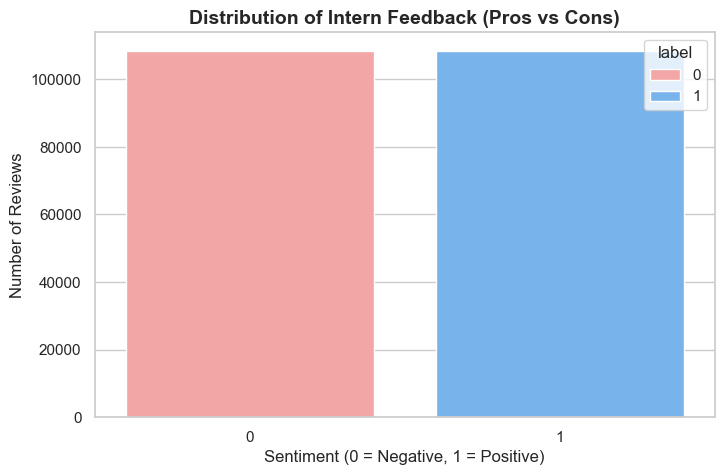

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's set a nice clean style for our charts
sns.set_theme(style="whitegrid")

# Create a bar chart showing how many Positives (1) and Negatives (0) we have
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label',hue='label', data=final_df, palette=['#ff9999', '#66b3ff'])

# Let's add some nice labels so people know what they are looking at
plt.title('Distribution of Intern Feedback (Pros vs Cons)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# This actually draws the graph on your screen
plt.show()

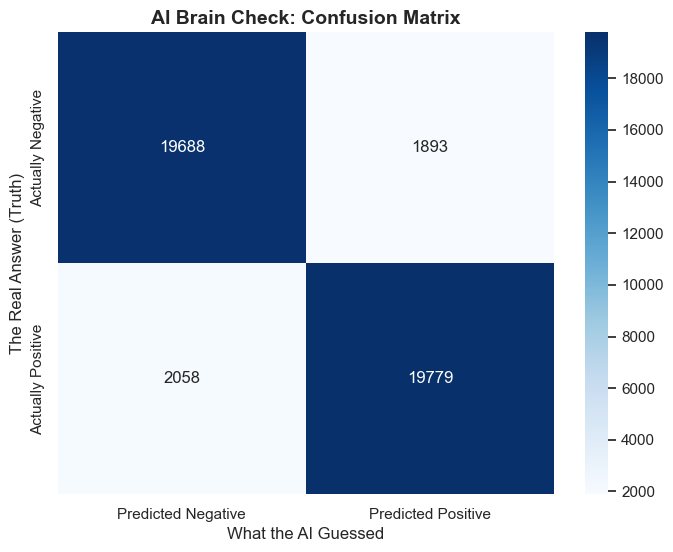

In [23]:
from sklearn.metrics import confusion_matrix

# Generate the raw numbers for the heatmap
cm = confusion_matrix(y_test, predictions)

# Set up the canvas
plt.figure(figsize=(8, 6))

# Create a beautiful heatmap using Seaborn
# 'Blues' is a nice professional color scheme. 'annot=True' prints the exact numbers inside the boxes.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actually Negative', 'Actually Positive'])

# Add the title and labels
plt.title('AI Brain Check: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('What the AI Guessed', fontsize=12)
plt.ylabel('The Real Answer (Truth)', fontsize=12)

# Draw the heatmap
plt.show()

In [25]:
# 1. Type any brand new custom sentence here to test the AI
custom_review = "The learning curve was steep and the hours were long, but the team's guidance made it worth every second."

# 2. Pass the text through our translator (TF-IDF) using the vocabulary it already knows
# We put the text inside a list [] because the translator expects an array of strings
translated_review = vectorizer.transform([custom_review])

# 3. Ask the model to guess the exact label (0 or 1)
prediction = model.predict(translated_review)[0]

# 4. Let's pull the underlying mathematical probabilities to see its confidence level
probabilities = model.predict_proba(translated_review)[0]
negative_chance = probabilities[0] * 100
positive_chance = probabilities[1] * 100

# 5. Print out the results clearly
print(f"Review Text: \"{custom_review}\"\n")
print(f"AI Prediction: {'Positive (Pros)' if prediction == 1 else 'Negative (Cons)'}")
print(f"Confidence: {positive_chance:.2f}% Positive vs {negative_chance:.2f}% Negative")

Review Text: "The learning curve was steep and the hours were long, but the team's guidance made it worth every second."

AI Prediction: Negative (Cons)
Confidence: 36.12% Positive vs 63.88% Negative
